In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [13]:
df = pd.read_csv(r"C:\Users\deeks\OneDrive\Desktop\ML\fruit_classification_dataset.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64

In [14]:
cat_cols = ["shape", "color", "taste"]
for i in cat_cols:
    print(df[i].value_counts())
    encoded_df = pd.get_dummies(df,columns= cat_cols)

shape
round    5016
oval     4482
long      502
Name: count, dtype: int64
color
green     2029
red       1943
brown     1541
yellow    1002
pink       998
orange     996
purple     988
blue       503
Name: count, dtype: int64
taste
sweet    7504
tangy    2015
sour      481
Name: count, dtype: int64


In [15]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   weight (g)     10000 non-null  float64
 2   avg_price (₹)  10000 non-null  float64
 3   fruit_name     10000 non-null  object 
 4   shape_long     10000 non-null  bool   
 5   shape_oval     10000 non-null  bool   
 6   shape_round    10000 non-null  bool   
 7   color_blue     10000 non-null  bool   
 8   color_brown    10000 non-null  bool   
 9   color_green    10000 non-null  bool   
 10  color_orange   10000 non-null  bool   
 11  color_pink     10000 non-null  bool   
 12  color_purple   10000 non-null  bool   
 13  color_red      10000 non-null  bool   
 14  color_yellow   10000 non-null  bool   
 15  taste_sour     10000 non-null  bool   
 16  taste_sweet    10000 non-null  bool   
 17  taste_tangy    10000 non-null  bool   
dtypes: bool

In [16]:
encoded_df.head()

,size (cm),weight (g),avg_price (₹),fruit_name,shape_long,shape_oval,shape_round,color_blue,color_brown,color_green,color_orange,color_pink,color_purple,color_red,color_yellow,taste_sour,taste_sweet,taste_tangy
0,25.4,3089.2,137.1,watermelon,False,False,True,False,False,True,False,False,False,False,False,False,True,False
1,24.6,3283.9,163.8,watermelon,False,False,True,False,False,True,False,False,False,False,False,False,True,False
2,7.8,319.0,91.3,custard apple,False,False,True,False,False,True,False,False,False,False,False,False,True,False
3,20.0,1607.0,85.7,papaya,False,True,False,False,False,False,True,False,False,False,False,False,True,False
4,10.2,131.5,37.8,banana,True,False,False,False,False,False,False,False,False,False,True,False,True,False


In [17]:
x = encoded_df.drop(columns="fruit_name",axis=1)
y = encoded_df["fruit_name"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rf = RandomForestClassifier(
max_depth = 3,
n_estimators = 50,
oob_score=False,
)
rf.fit(x_train,y_train)
pred_y = rf.predict(x_test)
print("accuracy_score: ",accuracy_score(y_test,pred_y))

accuracy_score:  0.9635


<function matplotlib.pyplot.show(close=None, block=None)>

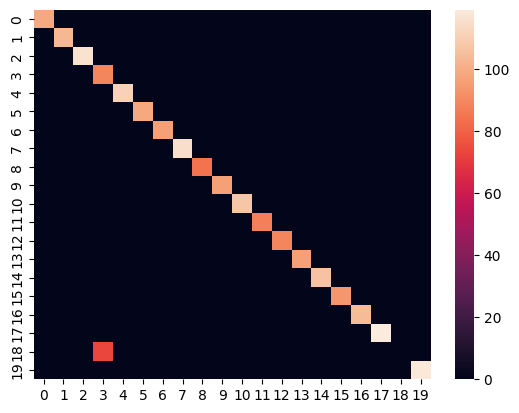

In [19]:
cm = confusion_matrix(y_test,pred_y)
sns.heatmap(cm)
plt.show

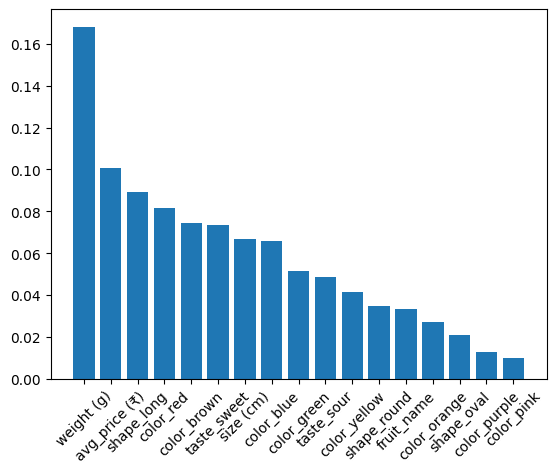

In [20]:
imp = rf.feature_importances_
index = np.argsort(imp)[::-1]
plt.figure()
plt.bar(range(len(imp)), imp[index])
plt.xticks(range(len(imp)), [encoded_df.columns[i] for i in index], rotation=45)
plt.show()